In [1]:
# Imports and helper plotting function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Helper function to plot decision boundary for 2D data
def plot_decision_boundary(clf, X, y, title="Decision boundary", plot_support=True):
    """
    clf: a fitted classifier with predict()
    X: 2D numpy array (n_samples, 2)
    y: labels (n_samples,)
    """
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    if plot_support and hasattr(clf, "support_vectors_"):
        sv = clf.support_vectors_
        plt.scatter(sv[:,0], sv[:,1], s=100, facecolors='none', edgecolors='k', linewidths=1.2, label='support vectors')
        plt.legend()
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

Support vectors count: 3


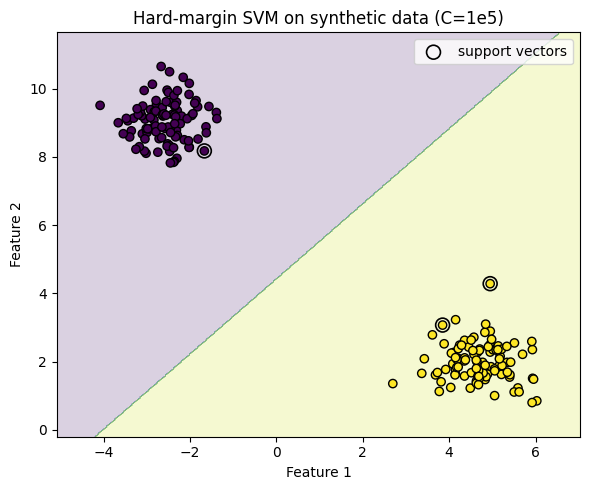

In [3]:
# 1) Hard-margin demo on synthetic linearly separable 2D data
X_blob, y_blob = make_blobs(n_samples=200, centers=2, cluster_std=0.6, random_state=42)
clf_hard_blob = SVC(kernel='linear', C=1e5)   # very large C approximates hard-margin
clf_hard_blob.fit(X_blob, y_blob)

print("Support vectors count:", len(clf_hard_blob.support_))
plot_decision_boundary(clf_hard_blob, X_blob, y_blob, title="Hard-margin SVM on synthetic data (C=1e5)")

In [4]:
# 2) Load Breast Cancer dataset and preprocess
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print("Breast Cancer dataset shape:", X.shape)   # (569, 30)

# Train-test split (70% train, 30% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42)

# Standardize features (fit on train, transform both train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quick peek at first 6 samples (unscaled)
pd.DataFrame(X[:6], columns=feature_names)


Breast Cancer dataset shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


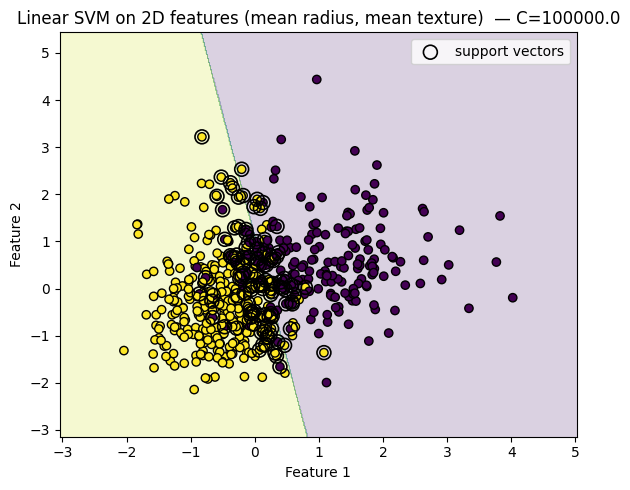

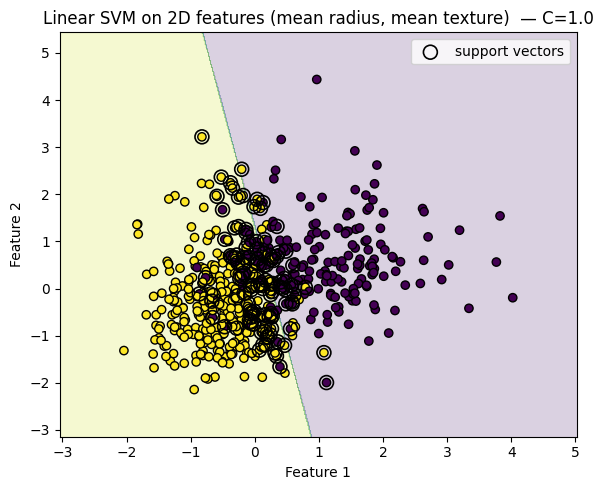

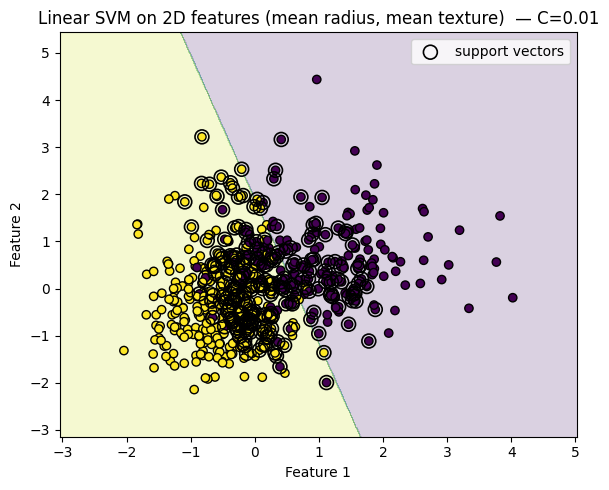

In [5]:
# 3) Soft vs Hard margin visualization on 2D projection
# Choose two features for visual clarity: 'mean radius' and 'mean texture'
feat1 = 'mean radius'
feat2 = 'mean texture'
idx1 = list(feature_names).index(feat1)
idx2 = list(feature_names).index(feat2)

X2 = X[:, [idx1, idx2]]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, train_size=0.7, stratify=y, random_state=42)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

# Train linear SVMs with different C values and plot
Cs = [1e5, 1.0, 0.01]
for C in Cs:
    clf = SVC(kernel='linear', C=C)
    clf.fit(X2_train_s, y2_train)
    title = f"Linear SVM on 2D features ({feat1}, {feat2})  — C={C}"
    plot_decision_boundary(clf, np.vstack((X2_train_s, X2_test_s)), np.hstack((y2_train, y2_test)), title=title)


In [6]:
# 4) Kernel experiments on full (scaled) features
models = {
    'linear': SVC(kernel='linear', C=1.0),
    'poly_deg3': SVC(kernel='poly', degree=3, C=1.0),
    'rbf_gamma_0.1': SVC(kernel='rbf', gamma=0.1, C=1.0)
}

results = []
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'confusion_matrix': cm
    })

# Show results as DataFrame (without confusion matrices)
results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='confusion_matrix'} for r in results])
display(results_df)

# Print confusion matrices and classification reports
for r in results:
    print("\nModel:", r['model'])
    print("Confusion Matrix:\n", r['confusion_matrix'])
    clf = models[r['model']]
    y_pred = clf.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=data.target_names))


,model,accuracy,precision,recall,f1
0,linear,0.982456,0.981481,0.990654,0.986047
1,poly_deg3,0.894737,0.856000,1.000000,0.922414
2,rbf_gamma_0.1,0.959064,0.980769,0.953271,0.966825



Model: linear
Confusion Matrix:
 [[ 62   2]
 [  1 106]]
              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


Model: poly_deg3
Confusion Matrix:
 [[ 46  18]
 [  0 107]]
              precision    recall  f1-score   support

   malignant       1.00      0.72      0.84        64
      benign       0.86      1.00      0.92       107

    accuracy                           0.89       171
   macro avg       0.93      0.86      0.88       171
weighted avg       0.91      0.89      0.89       171


Model: rbf_gamma_0.1
Confusion Matrix:
 [[ 62   2]
 [  5 102]]
              precision    recall  f1-score   support

   malignant       0.93      0.97      0.95        64
      benign       0.98      0.95      0.97       107

 

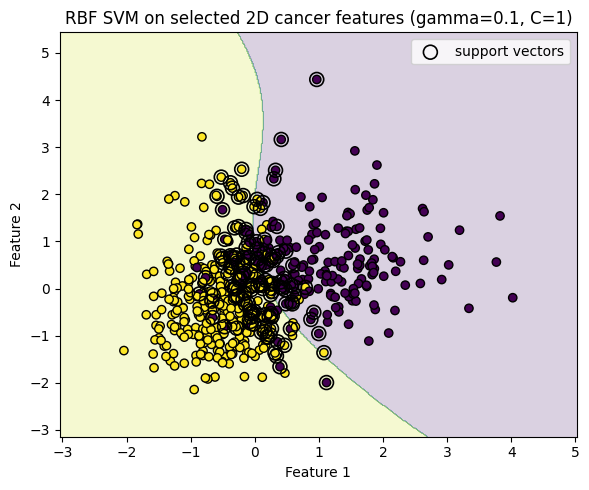

In [7]:
# 5) RBF decision boundary on selected 2D features for comparison
clf_rbf_2d = SVC(kernel='rbf', gamma=0.1, C=1.0)
clf_rbf_2d.fit(X2_train_s, y2_train)
plot_decision_boundary(clf_rbf_2d, np.vstack((X2_train_s, X2_test_s)), np.hstack((y2_train, y2_test)), title="RBF SVM on selected 2D cancer features (gamma=0.1, C=1)")
